# Deuteron NMR Lineshape Fit â€” Example
Fits an example signal from Run Group C at Jefferson Lab using both `deuteron_fit.fit` (absorption-only) and `deuteron_fit.fit_complex` (absorption + dispersion mixed by a phase angle).

In [50]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
from deuteron_fit import fit, fit_complex
import matplotlib.pyplot as plt
import json
import math

## Load example data

In [52]:
with open('example_data/example_data.json', 'r') as event:
    for line in event:
        json_dict = json.loads(line.rstrip('\n|\r'))
        signal = json_dict['fitsub']
        freqs  = json_dict['freq_list']

print(f'Loaded {len(freqs)} frequency points')

Loaded 512 frequency points


## Set initial parameters and run absorption-only fit (`fit`)

In [53]:
initial_params = {
    'A':    0.03,
    'G':   -0.00003,
    'r':    1.2,      # r > 1 is positive polarization
    'wQ':   0.027,
    'wL':   32.69,
    'eta': 0.2,
    'xi':  -0.001,
}

result = fit(freqs, signal, initial_params)
print(result.fit_report())

[[Model]]
    Model(_fit_func)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 93
    # data points      = 512
    # variables        = 7
    chi-square         = 1.9009e-07
    reduced chi-square = 3.7641e-10
    Akaike info crit   = -11103.6189
    Bayesian info crit = -11073.9506
    R-squared          = 0.99674322
[[Variables]]
    A:   -0.03286913 +/- 0.00110796 (3.37%) (init = 0.03)
    G:   -2.8173e-05 +/- 4.7704e-07 (1.69%) (init = -3e-05)
    r:    1.90998020 +/- 0.02664800 (1.40%) (init = 1.2)
    wQ:   0.02730058 +/- 2.4880e-05 (0.09%) (init = 0.027)
    wL:   32.6981462 +/- 8.2122e-05 (0.00%) (init = 32.69)
    eta:  0.10864553 +/- 0.00117080 (1.08%) (init = 0.2)
    xi:  -0.00504894 +/- 0.00741260 (146.82%) (init = -0.001)
[[Correlations]] (unreported correlations are < 0.100)
    C(G, r)   = +0.9731
    C(r, xi)  = -0.6369
    C(wQ, wL) = -0.5002
    C(A, eta) = +0.4969
    C(G, xi)  = -0.4823
    C(wL, xi) = -0.3345
    C(r, wL)  = +0.2165
  

## Calculate polarization

The asymmetry parameter `r` gives the vector polarization P and tensor polarization P$_{zz}$:

$$P = \frac{r^2 - 1}{r^2 + r + 1} \qquad P_{zz} = \frac{(r-1)^2}{r^2 + r + 1}$$

Errors are propagated from the fit uncertainty on `r`.

In [54]:
r      = result.params['r'].value
r_err  = result.params['r'].stderr
denom  = r**2 + r + 1

P   = (r**2 - 1) / denom
Pzz = (r - 1)**2 / denom

if r_err is not None:
    P_err   = (r**2 + 4*r + 1) / denom**2 * r_err
    Pzz_err = 3 * abs(r**2 - 1)  / denom**2 * r_err
    print(f'Vector polarization:  P   = {P*100:.2f} Â± {P_err*100:.2f}%')
    print(f'Tensor polarization:  Pzz = {Pzz*100:.2f} Â± {Pzz_err*100:.2f}%')
else:
    print(f'Vector polarization:  P   = {P*100:.2f}% (uncertainty unavailable)')
    print(f'Tensor polarization:  Pzz = {Pzz*100:.2f}% (uncertainty unavailable)')
    print('Warning: lmfit could not compute parameter uncertainties.')

Vector polarization:  P   = 40.38 Â± 0.76%
Tensor polarization:  Pzz = 12.63 Â± 0.49%


## Plot signal and fit

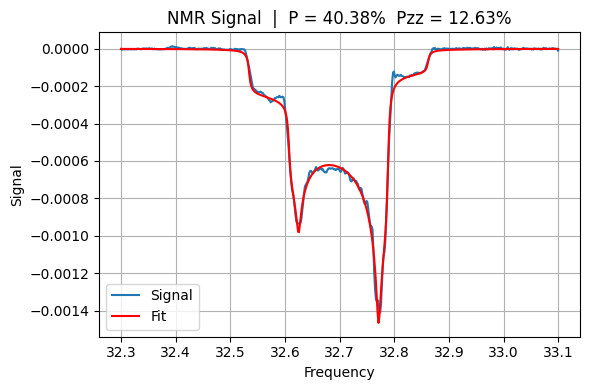

In [63]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freqs, signal, label='Signal')
ax.plot(freqs, result.best_fit, '-r', label='Fit')
ax.set_xlabel('Frequency')
ax.set_ylabel('Signal')
ax.set_title(f'NMR Signal  |  P = {P*100:.2f}%  Pzz = {Pzz*100:.2f}%')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

## Set initial parameters and run complex fit (`fit_complex`)

In [56]:
initial_params_c = {
    'A':    0.03,
    'G':   -0.00003,
    'r':    1.2,      # r > 1 is positive polarization
    'wQ':   0.027,
    'wL':   32.69,
    'eta':  0.2,
    'xi':  -0.001,
    'phase': 0.0,
}

result_c = fit_complex(freqs, signal, initial_params_c)
print(result_c.fit_report())

[[Model]]
    Model(_fit_func_complex)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 137
    # data points      = 512
    # variables        = 8
    chi-square         = 1.8677e-07
    reduced chi-square = 3.7057e-10
    Akaike info crit   = -11110.6377
    Bayesian info crit = -11076.7311
    R-squared          = 0.99680009
[[Variables]]
    A:     -0.03285756 +/- 0.00109781 (3.34%) (init = 0.03)
    G:     -2.8604e-05 +/- 5.0405e-07 (1.76%) (init = -3e-05)
    r:      1.88000166 +/- 0.02672389 (1.42%) (init = 1.2)
    wQ:     0.02737520 +/- 3.0541e-05 (0.11%) (init = 0.027)
    wL:     32.6981581 +/- 8.1685e-05 (0.00%) (init = 32.69)
    eta:    0.10813894 +/- 0.00116067 (1.07%) (init = 0.2)
    xi:     0.00932471 +/- 0.00834431 (89.49%) (init = -0.001)
    phase: -0.03138045 +/- 0.00917726 (29.25%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(G, r)      = +0.9740
    C(r, xi)     = -0.6621
    C(wQ, phase) = -0.5851
    C(G, 

## Calculate polarization (complex fit)

The asymmetry parameter `r` gives the vector polarization P and tensor polarization P$_{zz}$:

$$P = \frac{r^2 - 1}{r^2 + r + 1} \qquad P_{zz} = \frac{(r-1)^2}{r^2 + r + 1}$$

Errors are propagated from the fit uncertainty on `r`.

In [59]:
r_c      = result_c.params['r'].value
r_err_c  = result_c.params['r'].stderr
phase_c      = result_c.params['phase'].value
phase_err_c  = result_c.params['phase'].stderr
denom_c  = r_c**2 + r_c + 1

P_c   = (r_c**2 - 1) / denom_c
Pzz_c = (r_c - 1)**2 / denom_c

if r_err_c is not None:
    P_err_c   = (r_c**2 + 4*r_c + 1) / denom_c**2 * r_err_c
    Pzz_err_c = 3 * abs(r_c**2 - 1)  / denom_c**2 * r_err_c
    print(f'Vector polarization:  P   = {P_c*100:.2f} ± {P_err_c*100:.2f}%')
    print(f'Tensor polarization:  Pzz = {Pzz_c*100:.2f} ± {Pzz_err_c*100:.2f}%')
    print(f'Phase Offset:  {math.degrees(phase_c):.2f} ± {math.degrees(phase_err_c):.2f}°')
else:
    print(f'Vector polarization:  P   = {P_c*100:.2f}% (uncertainty unavailable)')
    print(f'Tensor polarization:  Pzz = {Pzz_c*100:.2f}% (uncertainty unavailable)')
    print('Warning: lmfit could not compute parameter uncertainties.')

Vector polarization:  P   = 39.51 ± 0.78%
Tensor polarization:  Pzz = 12.07 ± 0.49%
Phase Offset:  -1.80 ± 0.53°


## Plot signal and complex fit

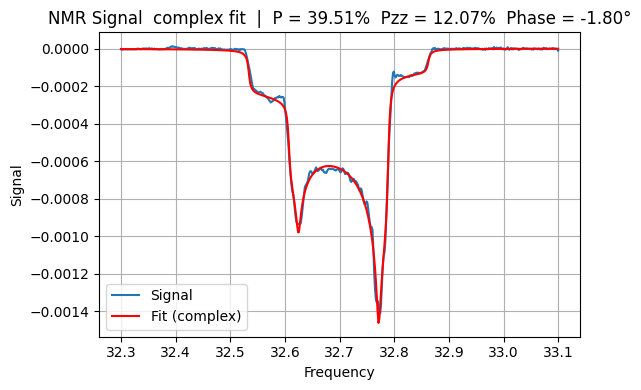

In [64]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(freqs, signal, label='Signal')
ax.plot(freqs, result_c.best_fit, '-r', label='Fit (complex)')
ax.set_xlabel('Frequency')
ax.set_ylabel('Signal')
ax.set_title(f'NMR Signal  complex fit  |  P = {P_c*100:.2f}%  Pzz = {Pzz_c*100:.2f}%  Phase = {math.degrees(phase_c):.2f}°')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()